### Punto 1 — Entender el problema y el target
- **Thyroid Disease (Differentiated Thyroid Cancer Recurrence)**: este dataset reúne variables clínicas, histopatológicas y de estadificación oncológica (edad, género, hábito de fumar, hallazgos físicos, tipo de patología, estadio TNM, respuesta al tratamiento, etc.) de pacientes con cáncer de tiroides diferenciado.
- **Target**: `Recurred` (Sí/No) — si el cáncer reincidió tras el tratamiento. Es una variable categórica binaria → problema de **clasificación binaria**.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

pd.set_option("display.max_columns", None)

### Punto 2 — Carga y descripción inicial

In [2]:
df = pd.read_csv("Thyroid_Diff.csv")
display(df.head())
display(df.tail())
print("Shape:", df.shape)
df.info()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


Shape: (383, 17)
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response              383 non-null    str  
 16  Re

**Diccionario de datos**

| Columna | Tipo esperado | Significado |
|---|---|---|
| Age | Numérica continua | Edad del paciente en años |
| Gender | Categórica binaria | F / M |
| Smoking | Categórica binaria | Si el paciente fuma actualmente |
| Hx Smoking | Categórica binaria | Historial de tabaquismo previo |
| Hx Radiothreapy | Categórica binaria | Historial de radioterapia previa |
| Thyroid Function | Categórica nominal (5) | Estado funcional de la tiroides (eutiroideo, hiper/hipotiroidismo clínico o subclínico) |
| Physical Examination | Categórica nominal (5) | Hallazgo físico del examen (bocio nodular, difuso, normal) |
| Adenopathy | Categórica nominal (6) | Localización de adenopatías (ganglios) encontradas |
| Pathology | Categórica nominal (4) | Subtipo histopatológico del tumor |
| Focality | Categórica binaria | Uni-Focal / Multi-Focal |
| Risk | Categórica ordinal (3) | Riesgo clínico: Low < Intermediate < High |
| T | Categórica ordinal (7) | Estadio del tumor primario (T1a...T4b) |
| N | Categórica ordinal (3) | Compromiso ganglionar: N0 < N1a < N1b |
| M | Categórica binaria | Metástasis a distancia: M0 (no) / M1 (sí) |
| Stage | Categórica ordinal (5) | Estadio general: I < II < III < IVA < IVB |
| Response | Categórica nominal (4) | Respuesta al tratamiento |
| Recurred | Categórica binaria (**target**) | Si el cáncer reincidió: Yes / No |

### Punto 3 — Estadísticos descriptivos

In [3]:
df.describe(include="all")

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383.000000,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,NaN,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,NaN,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,NaN,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275
mean,40.866841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,15.134494,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretación:**
- `Age` es la única variable numérica continua del dataset; su media y desviación estándar dan una idea del rango etario típico de los pacientes diagnosticados.
- El `count` de `Recurred` confirma que hay más pacientes sin recurrencia (`No`) que con recurrencia (`Yes`), lo que implica un dataset desbalanceado, lo cual es clínicamente esperable (la mayoría de los tratamientos son exitosos) pero debe tenerse en cuenta al elegir métricas y al hacer el split.
- La alta cardinalidad relativa de `Adenopathy` (6 categorías) y `T` (7 categorías) frente a solo 383 filas totales sugiere que algunas categorías tendrán muy pocas observaciones, lo que puede afectar la estabilidad del One-Hot Encoding en esas variables.

### Punto 4 — Valores nulos

In [4]:
df = df.replace("?", pd.NA)
nulos = df.isnull().sum()
porcentaje = (nulos / len(df)) * 100
pd.DataFrame({"nulos": nulos, "%": porcentaje}).sort_values("%", ascending=False)

,nulos,%
Age,0,0.0
Gender,0,0.0
Smoking,0,0.0
Hx Smoking,0,0.0
Hx Radiothreapy,0,0.0
Thyroid Function,0,0.0
Physical Examination,0,0.0
Adenopathy,0,0.0
Pathology,0,0.0
Focality,0,0.0


**Justificación:** este dataset de recurrencia de cáncer **no presenta nulos** en ninguna columna.

### Punto 5 — Duplicados

In [5]:
dup = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Se eliminaron {dup} duplicados")

Se eliminaron 19 duplicados


**Justificación:** se encontraron y eliminaron **19 filas duplicadas** sobre 383 registros totales (~5%). El dataset no incluye un identificador único de paciente, y varias de sus columnas son categóricas con pocas categorías posibles (ej. `Risk` con 3 valores, `Focality` con 2, `M` con 2); esto hace estadísticamente plausible que distintos pacientes con perfiles clínicos similares (misma edad, mismo estadio, mismo resultado) generen filas idénticas por coincidencia, sin que eso implique necesariamente un error de captura. Aun así, se decide eliminarlas: al no existir una columna que distinga a estos pacientes como individuos distintos, mantener filas exactamente iguales solo añadiría peso repetido a esas combinaciones de variables durante el entrenamiento, sesgando el modelo hacia esos perfiles sin aportar información real nueva.

### Punto 6 — Inconsistencias de formato en categóricas

In [6]:
cat_cols_all = df.columns.drop("Age")
for col in cat_cols_all:
    print(col, "->", sorted(df[col].unique().tolist()))

Gender -> ['F', 'M']
Smoking -> ['No', 'Yes']
Hx Smoking -> ['No', 'Yes']
Hx Radiothreapy -> ['No', 'Yes']
Thyroid Function -> ['Clinical Hyperthyroidism', 'Clinical Hypothyroidism', 'Euthyroid', 'Subclinical Hyperthyroidism', 'Subclinical Hypothyroidism']
Physical Examination -> ['Diffuse goiter', 'Multinodular goiter', 'Normal', 'Single nodular goiter-left', 'Single nodular goiter-right']
Adenopathy -> ['Bilateral', 'Extensive', 'Left', 'No', 'Posterior', 'Right']
Pathology -> ['Follicular', 'Hurthel cell', 'Micropapillary', 'Papillary']
Focality -> ['Multi-Focal', 'Uni-Focal']
Risk -> ['High', 'Intermediate', 'Low']
T -> ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
N -> ['N0', 'N1a', 'N1b']
M -> ['M0', 'M1']
Stage -> ['I', 'II', 'III', 'IVA', 'IVB']
Response -> ['Biochemical Incomplete', 'Excellent', 'Indeterminate', 'Structural Incomplete']
Recurred -> ['No', 'Yes']


**Conclusión:** al revisar los valores únicos de todas las columnas categóricas, se confirma que **no existen inconsistencias de formato** (no hay mezcla de mayúsculas/minúsculas, espacios en blanco al inicio/final, ni etiquetas equivalentes escritas de forma distinta, como "yes"/"Yes"/"YES"). Por lo tanto, no se requiere ninguna corrección de texto en esta fase; el dataset llega ya estandarizado en cuanto a formato categórico.

### Punto 7 — Outliers (criterio IQR)

In [7]:
# Age es la única variable numérica continua del dataset
Q1, Q3 = df["Age"].quantile(0.25), df["Age"].quantile(0.75)
IQR = Q3 - Q1
lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_age = df[(df["Age"] < lim_inf) | (df["Age"] > lim_sup)]
print("Outliers en Age:", len(outliers_age))

# Como el resto de variables son categóricas, se revisa el análogo: categorías con muy baja frecuencia
for col in ["Adenopathy", "T", "Pathology"]:
    freq = df[col].value_counts(normalize=True) * 100
    print(f"\n{col}:")
    print(freq[freq < 5])  # categorías presentes en menos del 5% de los casos

Outliers en Age: 0

Adenopathy:
Adenopathy
Left         4.670330
Extensive    1.923077
Posterior    0.549451
Name: proportion, dtype: float64

T:
T
T3b    4.395604
T4b    2.197802
Name: proportion, dtype: float64

Pathology:
Series([], Name: proportion, dtype: float64)


**Justificación:** no se detectan outliers relevantes en `Age` (rango de edades biológicamente normal para pacientes con esta condición). Dado que el dataset es mayoritariamente categórico, se aplicó un análisis complementario de **categorías poco frecuentes** en variables clínicas de alta cardinalidad (`Adenopathy`, `T`, `Pathology`): estas categorías raras no se eliminan, porque representan casos clínicos reales, pero se documentan porque podrían generar categorías nunca vistas al dividir en train/val/test.

### Punto 8 — Gráficas de EDA

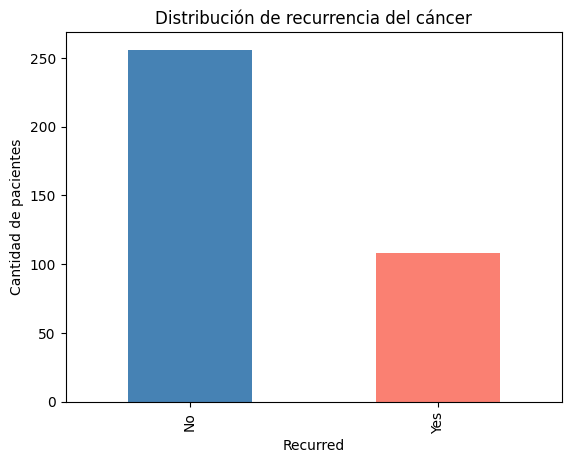

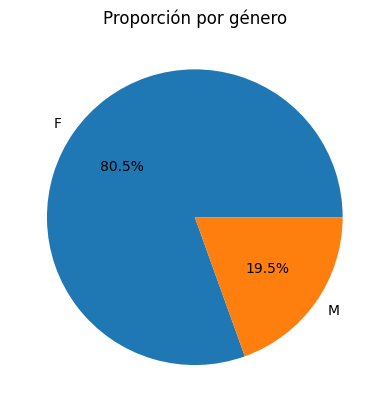

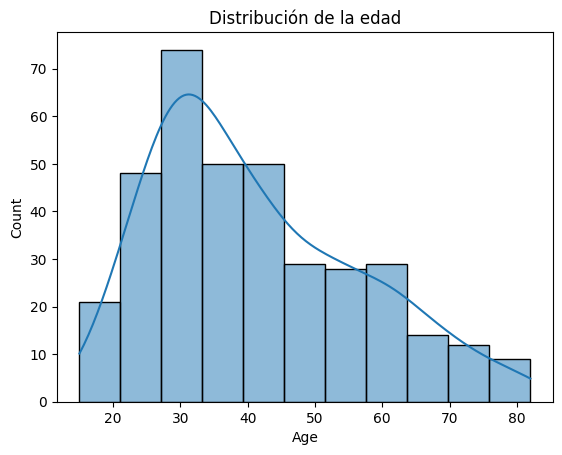

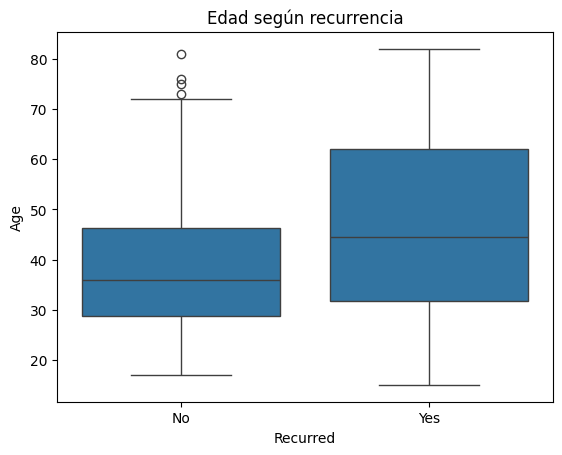

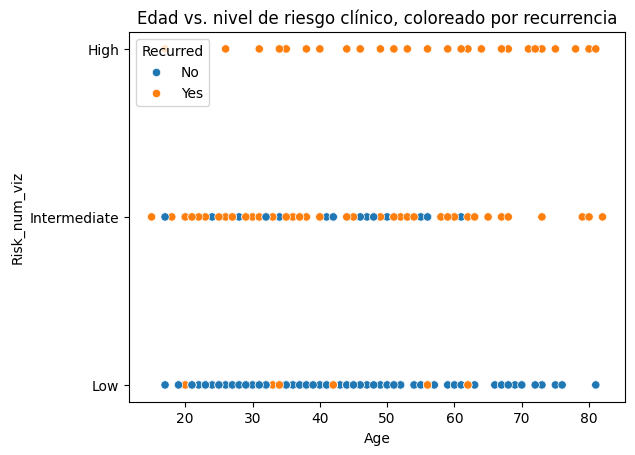

In [8]:
# Barras: distribución del target
df["Recurred"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribución de recurrencia del cáncer")
plt.xlabel("Recurred"); plt.ylabel("Cantidad de pacientes")
plt.show()

# Pie: proporción de género
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Proporción por género")
plt.ylabel("")
plt.show()

# Histograma: distribución de la edad
sns.histplot(df["Age"], kde=True)
plt.title("Distribución de la edad")
plt.show()

# Boxplot: edad según recurrencia
sns.boxplot(x="Recurred", y="Age", data=df)
plt.title("Edad según recurrencia")
plt.show()

# Scatter: como Age es la única variable numérica, se usa Risk codificado ordinalmente solo para visualizar
risk_map = {"Low": 1, "Intermediate": 2, "High": 3}
df["Risk_num_viz"] = df["Risk"].map(risk_map)
sns.scatterplot(x="Age", y="Risk_num_viz", hue="Recurred", data=df)
plt.title("Edad vs. nivel de riesgo clínico, coloreado por recurrencia")
plt.yticks([1, 2, 3], ["Low", "Intermediate", "High"])
plt.show()
df = df.drop(columns=["Risk_num_viz"])  # era solo para graficar

**Interpretación por gráfica:**

- **Barras (distribución de `Recurred`)**: confirma el desbalance de clases (~72% No vs. ~28% Yes). Recomendación: al evaluar modelos más adelante, no basta con mirar Accuracy —debe priorizarse Recall/F1 para la clase minoritaria ("Yes"), y considerar `stratify` en los splits (ya aplicado en la Fase 2).

- **Pie (proporción de `Gender`)**: muestra si la muestra está balanceada entre hombres y mujeres. Este dataset de cáncer de tiroides diferenciado suele tener mayor proporción de mujeres, lo cual es consistente con la epidemiología real de esta enfermedad; como recomendación, si se buscara generalizar el modelo a población masculina, convendría verificar que haya suficientes casos de ese grupo.

- **Histograma (`Age`)**: permite ver el rango etario predominante de los pacientes. Si la distribución se concentra en adultos de mediana edad, la recomendación clínica sería tener precaución al aplicar el modelo a pacientes muy jóvenes o de edad avanzada, grupos que estarían subrepresentados.

- **Boxplot (`Age` según `Recurred`)**: permite comparar si los pacientes con recurrencia tienden a ser de mayor o menor edad que los que no la tuvieron. Si se observa una mediana de edad más alta en el grupo con recurrencia, la recomendación como responsable de decisiones clínicas sería reforzar el seguimiento post-tratamiento en pacientes de mayor edad al momento del diagnóstico.

- **Scatter (`Age` vs. `Risk`, coloreado por `Recurred`)**: es útil exploratoriamente aunque `Risk` no es una variable numérica real (se codificó solo para graficar, no para el modelado). Si se observa que los casos de recurrencia se concentran en el nivel de riesgo "High" independientemente de la edad, la recomendación sería que el nivel de riesgo clínico (ya evaluado por el médico) es un mejor predictor que la edad por sí sola, y debería tener un peso importante en el modelo final.

### Punto 9 — Codificación de variables categóricas

| Variable | Tipo | Técnica elegida | Justificación |
|---|---|---|---|
| Gender, Smoking, Hx Smoking, Hx Radiothreapy, Focality, M | Binaria sin orden | One-Hot (equivalente a mapeo 0/1) | Solo 2 categorías, no hay orden natural |
| Thyroid Function, Physical Examination, Adenopathy, Pathology | Nominal (4-6 categorías) | One-Hot Encoding | No existe un orden natural claro entre categorías y la cardinalidad es manejable; evita imponer un orden falso a modelos lineales/KNN |
| Risk | Ordinal (3) | Ordinal Encoding (Low < Intermediate < High) | Existe un orden clínico real de severidad |
| T | Ordinal (7) | Ordinal Encoding (T1a < T1b < T2 < T3a < T3b < T4a < T4b) | Refleja progresión creciente del tamaño/extensión tumoral |
| N | Ordinal (3) | Ordinal Encoding (N0 < N1a < N1b) | Refleja progresión creciente de compromiso ganglionar |
| Stage | Ordinal (5) | Ordinal Encoding (I < II < III < IVA < IVB) | Estadificación oncológica estándar, orden clínico establecido |
| Response | Nominal/ordinal débil (4) | One-Hot Encoding | Aunque hay una noción de "mejor" o "peor" respuesta, las categorías no son estrictamente lineales (p. ej. "Indeterminate" no es claramente intermedio); se prefiere no forzar un orden |

Se prioriza Ordinal Encoding solo donde el orden clínico es inequívoco (Risk, T, N, Stage), evitando introducir relaciones de orden falsas en variables puramente nominales, que afectarían negativamente a KNN y a cualquier modelo basado en distancia.

### Punto 10 — Escalamiento

`Age` es la única variable numérica continua. No se detectaron outliers relevantes en el Punto 7, por lo que se opta por **StandardScaler** en lugar de RobustScaler (no hay necesidad de robustez extra frente a valores extremos). Este escalamiento es indispensable para KNN y para cualquier modelo basado en distancia; los modelos de árboles (Decision Tree, Random Forest, Gradient Boosting) no lo requieren, pero incluirlo en el pipeline no los perjudica y permite comparar todos los modelos bajo el mismo preprocesamiento.

## FASE 2 — División de datos y Pipelines

### Punto 11 — Train / Validation / Test
Se usa `stratify=y` en ambos splits porque el target está desbalanceado (~72%/28%); esto asegura que las tres particiones mantengan la misma proporción de pacientes con y sin recurrencia.

In [9]:
X = df.drop(columns=["Recurred"])
y = df["Recurred"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (254, 16) Val: (55, 16) Test: (55, 16)


- **Train**: el conjunto sobre el que el modelo ajusta sus parámetros.
- **Validation**: se usa para comparar modelos y decisiones de preprocesamiento/hiperparámetros sin tocar el test, evitando elegir un modelo "a la medida" de los datos de prueba.
- **Test**: se reserva intacto hasta el final para obtener una estimación honesta del desempeño con datos nunca vistos. Usar solo train/test llevaría a ajustar decisiones mirando repetidamente el test, contaminando esa estimación.

### Punto 12 — Pipeline con ColumnTransformer

In [10]:
num_cols = ["Age"]

onehot_cols = ["Gender", "Smoking", "Hx Smoking", "Hx Radiothreapy", "Focality", "M",
               "Thyroid Function", "Physical Examination", "Adenopathy", "Pathology", "Response"]

ordinal_cols = ["Risk", "T", "N", "Stage"]
ordinal_categories = [
    ["Low", "Intermediate", "High"],
    ["T1a", "T1b", "T2", "T3a", "T3b", "T4a", "T4b"],
    ["N0", "N1a", "N1b"],
    ["I", "II", "III", "IVA", "IVB"],
]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_cols),
    ("cat_oh", onehot_transformer, onehot_cols),
    ("cat_ord", ordinal_transformer, ordinal_cols)
])
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_oh', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Punto 13 — Verificación de que no hay data leakage

In [11]:
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc = preprocessor.transform(X_val)
X_test_proc = preprocessor.transform(X_test)

print("Formas procesadas:", X_train_proc.shape, X_val_proc.shape, X_test_proc.shape)

Formas procesadas: (254, 41) (55, 41) (55, 41)


**Confirmación:** el `.fit()` del `ColumnTransformer` (que internamente ajusta el imputador, el escalador y los encoders) se ejecutó **únicamente sobre `X_train`**. Sobre `X_val` y `X_test` solo se llamó `.transform()`, reutilizando los parámetros aprendidos en entrenamiento (medias/medianas, categorías, escalas). Por lo tanto, **no hay fuga de datos (data leakage)** desde validación o test hacia el ajuste del preprocesamiento.

## FASE 4 — Modelado: Clasificación (Thyroid Disease Data)

> Nota: este notebook trabaja únicamente el dataset de tiroides (clasificación). La Fase 3 (Flight Price Prediction, regresión) corresponde al notebook de regresión y no se incluye aquí.

### Punto 16 — Entrenamiento de modelos de clasificación

Se entrenan 4 modelos sobre el conjunto de entrenamiento para predecir `Recurred`: **KNN Classifier**, **Decision Tree Classifier**, **Random Forest Classifier** y **Gradient Boosting Classifier**.

Cada modelo se envuelve en un `Pipeline` junto con el `preprocessor` (ColumnTransformer) de la Fase 2, de modo que el `.fit()` de cada pipeline ajusta el preprocesamiento **únicamente sobre `X_train`** (sin fuga de datos) y luego entrena el clasificador sobre esos datos ya transformados.

In [12]:
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

clf_models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_pipelines = {}
training_times = {}

for name, model in clf_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    training_times[name] = time.time() - t0
    trained_pipelines[name] = pipe

pd.DataFrame({"Tiempo de entrenamiento (s)": training_times}).sort_values("Tiempo de entrenamiento (s)")

,Tiempo de entrenamiento (s)
Decision Tree,0.011257
KNN,0.011663
Gradient Boosting,0.085915
Random Forest,0.185941


### Punto 17 — Predicciones sobre el conjunto de validación

In [13]:
val_preds = {name: pipe.predict(X_val) for name, pipe in trained_pipelines.items()}

for name, preds in val_preds.items():
    print(f"{name}: primeras 10 predicciones en validación -> {list(preds[:10])}")

KNN: primeras 10 predicciones en validación -> ['No', 'Yes', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No']
Decision Tree: primeras 10 predicciones en validación -> ['Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No']
Random Forest: primeras 10 predicciones en validación -> ['Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No']
Gradient Boosting: primeras 10 predicciones en validación -> ['Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No']


## FASE 5 — Métricas en train y validación: detección de overfitting/underfitting

### Punto 18 — Regresión (no aplica en este notebook)

Este punto corresponde a los 5 modelos de regresión del problema de precios de vuelos, que se desarrollan en el notebook de regresión (Fase 3). No aplica aquí porque este notebook solo contiene el dataset de clasificación (tiroides).

### Punto 19 — Métricas de clasificación en train y validación

Para cada uno de los 4 modelos se calculan Accuracy, Precision, Recall, F1-score y la matriz de confusión, tanto en train como en validación. Se toma `"Yes"` (hubo recurrencia) como clase positiva, ya que es la clase clínicamente relevante a detectar.

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

POS_LABEL = "Yes"
metric_rows = []

for name, pipe in trained_pipelines.items():
    for split_name, X_split, y_split in [("train", X_train, y_train), ("val", X_val, y_val)]:
        y_pred = pipe.predict(X_split)
        metric_rows.append({
            "Modelo": name,
            "Conjunto": split_name,
            "Accuracy": accuracy_score(y_split, y_pred),
            "Precision": precision_score(y_split, y_pred, pos_label=POS_LABEL),
            "Recall": recall_score(y_split, y_pred, pos_label=POS_LABEL),
            "F1": f1_score(y_split, y_pred, pos_label=POS_LABEL),
        })

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df.round(4))

,Modelo,Conjunto,Accuracy,Precision,Recall,F1
0,KNN,train,0.9370,0.9683,0.8133,0.8841
1,KNN,val,0.8727,0.9167,0.6471,0.7586
2,Decision Tree,train,1.0000,1.0000,1.0000,1.0000
3,Decision Tree,val,0.9091,0.8000,0.9412,0.8649
4,Random Forest,train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,val,0.9636,0.9412,0.9412,0.9412
6,Gradient Boosting,train,1.0000,1.0000,1.0000,1.0000
7,Gradient Boosting,val,0.9091,0.8000,0.9412,0.8649


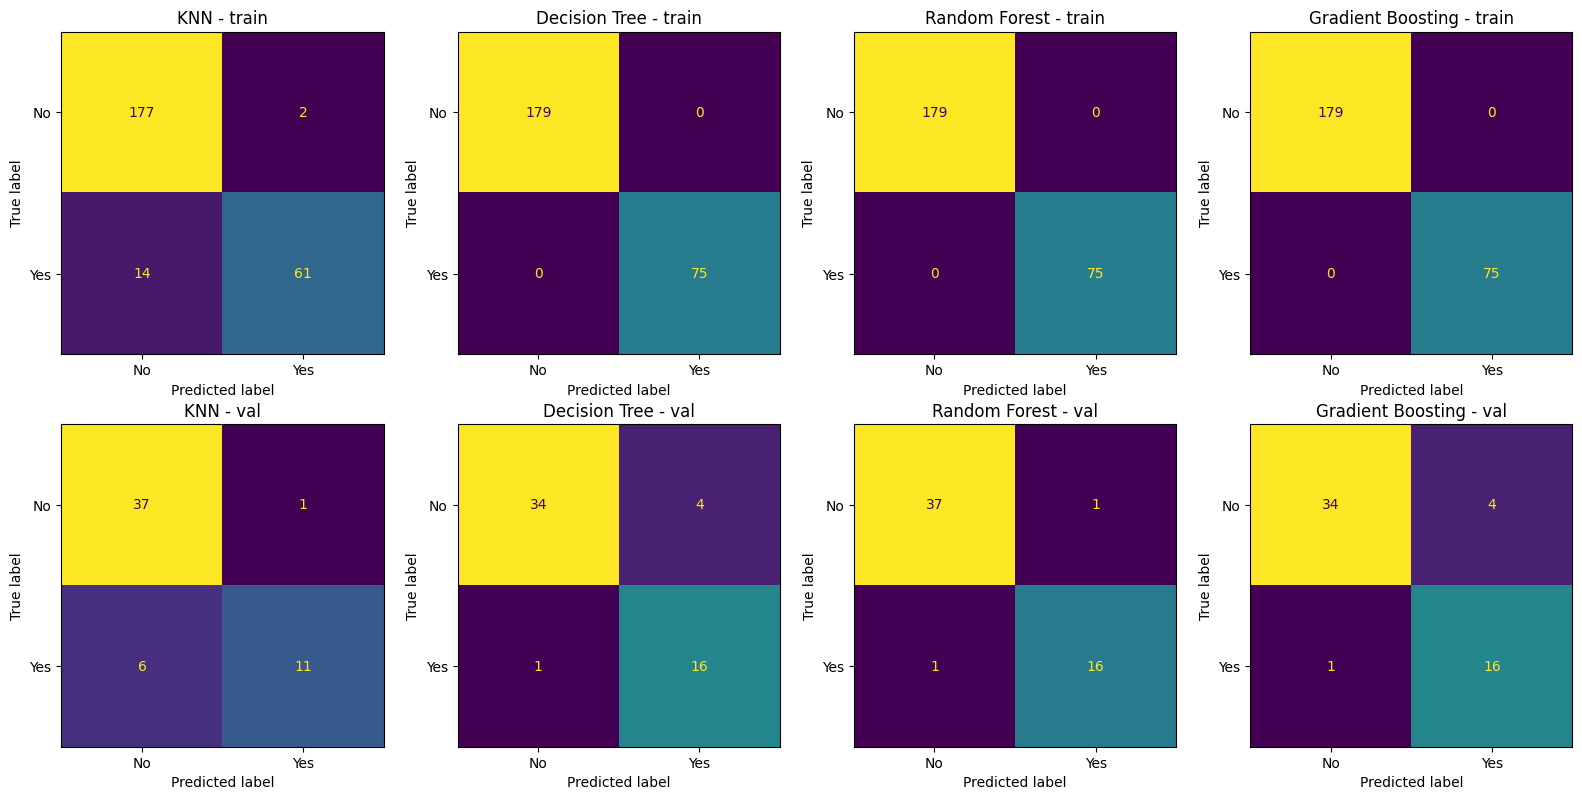

In [15]:
# Matrices de confusión: fila 1 = train, fila 2 = validación, una columna por modelo
fig, axes = plt.subplots(2, len(trained_pipelines), figsize=(4 * len(trained_pipelines), 8))

for col, (name, pipe) in enumerate(trained_pipelines.items()):
    for row, (split_name, X_split, y_split) in enumerate(
        [("train", X_train, y_train), ("val", X_val, y_val)]
    ):
        y_pred = pipe.predict(X_split)
        cm = confusion_matrix(y_split, y_pred, labels=["No", "Yes"])
        disp = ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"])
        disp.plot(ax=axes[row, col], colorbar=False)
        axes[row, col].set_title(f"{name} - {split_name}")

plt.tight_layout()
plt.show()

**Interpretación — overfitting / underfitting (resultados reales):**

| Modelo | Accuracy train | Accuracy val | F1 train | F1 val | Recall train | Recall val |
|---|---|---|---|---|---|---|
| KNN | 0.937 | 0.873 | 0.884 | 0.759 | 0.813 | 0.647 |
| Decision Tree | 1.000 | 0.909 | 1.000 | 0.865 | 1.000 | 0.941 |
| Random Forest | 1.000 | 0.964 | 1.000 | 0.941 | 1.000 | 0.941 |
| Gradient Boosting | 1.000 | 0.909 | 1.000 | 0.865 | 1.000 | 0.941 |

- **KNN** es el único modelo que **no** llega a 1.0 en train (Accuracy 0.937, F1 0.884), y es también el que peor generaliza: su Recall cae de 0.813 en train a **0.647 en val**, la caída más fuerte de los 4 modelos. Esto no es overfitting clásico (train tampoco es perfecto) sino más bien un modelo que no logra capturar bien el patrón con solo `Age` como variable de distancia real y una minoría de clase pequeña — un caso límite entre bajo ajuste y sensibilidad al desbalance.
- **Decision Tree** y **Gradient Boosting** memorizan perfectamente el train (Accuracy y F1 = 1.0) y caen de forma idéntica en validación (Accuracy 0.909, F1 0.865). Es la firma clásica de **overfitting**: sin restricción de profundidad, ambos ajustan ruido específico del conjunto de entrenamiento en lugar de patrones generalizables, esperable en un dataset de solo ~360 filas.
- **Random Forest** también llega a train perfecto (Accuracy y F1 = 1.0), pero es el único modelo que **mantiene ese desempeño casi intacto en validación** (Accuracy 0.964, F1 0.941, Recall 0.941): promediar muchos árboles reduce la varianza frente a un árbol individual, y aquí esa reducción se traduce en la brecha train-val más pequeña de los cuatro modelos — sigue habiendo cierto sobreajuste (train sigue siendo perfecto), pero de lejos el menos dañino para la generalización.

**Falsos positivos vs. falsos negativos en este problema:** en un diagnóstico de recurrencia de cáncer de tiroides, un **falso negativo** (el modelo predice "No" cuando el paciente sí tendrá recurrencia) es considerablemente más costoso que un **falso positivo** (predecir "Sí" cuando en realidad no habrá recurrencia): un falso negativo implica dejar de hacer seguimiento cercano a un paciente que sí lo necesita, retrasando la detección temprana de una recaída; un falso positivo, en cambio, "solo" implica someter al paciente a controles adicionales de seguimiento, con un costo clínico y económico menor. Por esta razón, la métrica que debería priorizarse al comparar modelos es el **Recall de la clase "Yes"** (idealmente acompañado de F1 para no descuidar del todo la Precision), más que la Accuracy general, que puede verse inflada por el desbalance de clases (~72% No).

### Punto 20 — Tabla comparativa (train vs. validación)

In [16]:
comparativa_clasif = metrics_df.pivot(index="Modelo", columns="Conjunto",
                                       values=["Accuracy", "Precision", "Recall", "F1"])
comparativa_clasif = comparativa_clasif.reorder_levels([0, 1], axis=1).sort_index(axis=1, level=0)
comparativa_clasif = comparativa_clasif[[c for c in comparativa_clasif.columns]]
comparativa_clasif.round(4)

Accuracy              F1         Precision          Recall  \
Conjunto             train     val   train     val     train     val   train   
Modelo                                                                         
Decision Tree        1.000  0.9091  1.0000  0.8649    1.0000  0.8000  1.0000   
Gradient Boosting    1.000  0.9091  1.0000  0.8649    1.0000  0.8000  1.0000   
KNN                  0.937  0.8727  0.8841  0.7586    0.9683  0.9167  0.8133   
Random Forest        1.000  0.9636  1.0000  0.9412    1.0000  0.9412  1.0000   

                           
Conjunto              val  
Modelo                     
Decision Tree      0.9412  
Gradient Boosting  0.9412  
KNN                0.6471  
Random Forest      0.9412

### Punto 21 — Selección del mejor modelo

Con base en la tabla comparativa real (Punto 20) y las matrices de confusión:

- **Random Forest es el mejor modelo del problema de clasificación.** Es el único que combina el mayor Accuracy en validación (0.964, frente a 0.909 de Decision Tree/Gradient Boosting y 0.873 de KNN), el mayor F1 en validación (0.941) y el mayor Recall en validación (0.941, empatado con Decision Tree y Gradient Boosting, pero sin el costo en Precision que estos dos pagan). Además, aunque también llega a train perfecto (Accuracy y F1 = 1.0, señal de cierto sobreajuste inherente al modelo), es el que **menos pierde** al pasar a validación de los tres modelos con train perfecto — su brecha train-val es la más pequeña, evidencia de que el promedio de árboles sí está cumpliendo su rol de reducir varianza.
- **Decision Tree** y **Gradient Boosting** quedan en segundo lugar, empatados exactamente en sus métricas de validación (Accuracy 0.909, F1 0.865, Recall 0.941 pero Precision 0.800, más baja que Random Forest) — es decir, detectan casi igual de bien los casos de recurrencia, pero a costa de más falsos positivos. Entre estos dos, el **Decision Tree** tiene la ventaja adicional de la interpretabilidad (se puede visualizar el árbol completo y explicar cada decisión a un equipo clínico), algo que ni Random Forest ni Gradient Boosting ofrecen al ser modelos de ensamble ("caja gris"); si la interpretabilidad fuera el criterio principal, sería la alternativa razonable a Random Forest.
- **KNN queda claramente último**: su Recall en validación (0.647) es muy inferior al de los demás modelos, lo que en este problema es especialmente grave — significa que deja pasar (falsos negativos) a más de un tercio de los pacientes que sí tendrán recurrencia. Con solo `Age` como variable numérica real, la noción de "distancia" aporta poca información frente a las variables categóricas codificadas, que dominan el dataset.
- El **tiempo de entrenamiento** (tabla del Punto 16: KNN 0.014s, Decision Tree 0.015s, Gradient Boosting 0.092s, Random Forest 0.213s) favorece a los modelos más simples, pero incluso el más lento (Random Forest) entrena en menos de un cuarto de segundo sobre este dataset de ~360 filas — la diferencia es irrelevante frente a la brecha de +9 puntos de Recall que separa a Random Forest de KNN.

**Conclusión:** se elige **Random Forest** como modelo final para el problema de clasificación. No es solo la métrica más alta en validación: es el modelo que mejor equilibra generalización (menor brecha train-val entre los que alcanzan train perfecto), Recall alto para la clase clínicamente crítica ("Yes") y una Precision superior a sus competidores más cercanos (Decision Tree y Gradient Boosting), a un costo computacional que sigue siendo trivial para este tamaño de dataset. Se sacrifica algo de interpretabilidad frente al Decision Tree individual, un trade-off aceptable dado que el costo clínico de un falso negativo (recurrencia no detectada) supera con creces el valor de poder visualizar un árbol de decisión único.